# Seq2Seq2 — source vs target onsets, one sample from `configs/midi-seq2seq2.yaml`

The feeder pairs two renderings of the same piece: it crops a mark-aligned window out of the
**source**, finds the window covering the same music in the **target**, and emits ONE flat id
sequence `source <sep> target`. This notebook loads a sample straight from the training config,
decodes both halves back into note onsets, and draws them stacked so the pairing can be read by eye.

**The x axis is real MIDI tick, each half scaled by its own total span.** So both panels span the
full width and a note's x is its actual performed time — nothing is quantized or snapped to the bar.
The consequence, and the point of drawing it this way: **the bar lines do NOT line up between the
panels**, and how they fail to line up IS the relative tempo. A performance arm that pulls ahead
early has its bar lines sitting left of the score's; one that broadens has them drifting right.

Bar lines come from the `<eom>` tokens at bar boundaries. The target half carries them by default and
the source half does not, so this notebook turns `source_eom` on to annotate both panels alike. That
is a **visualization** setting; the shipped config leaves it off because the source is a read-only
condition whose bar structure is already implied by its content.

> An earlier version of this notebook normalized each bar by its own span, which put the bar lines on
> integers in both panels. That view answers "did the crop align?" (it did — the arms agree to ~0.014
> bar units once tempo is divided out) but it *hides* tempo by construction, which is most of what
> distinguishes the two arms. §7 keeps that measurement as a number; the plot now shows tempo.

In [1]:
%matplotlib inline
from pathlib import Path
import sys

REPO_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'starry').is_dir())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np

from starry.utils.config import Configuration
from starry.midi.data.seq2seq2 import Seq2Seq2

CONFIG = REPO_ROOT / 'configs' / 'midi-seq2seq2.yaml'

## 1. Load the dataset from the config

Read the `data:` block as the trainer would, then override three args for the sake of the picture:

- `source_eom` — bar tokens on both halves, so both panels can be annotated.
- `random_crop=False` — a re-run shows the same sample instead of a fresh one.
- `line_range` — the config samples the cap per crop, which is right for training but would make a
  re-run's picture a different width each time. A single wide value is pinned here so several bars are
  always in view (a measure averages ~104 lines, so the config's own median lands near one or two bars,
  and one bar cannot show a tempo trend). It does not change what the feeder does.

In [2]:
config = Configuration.createOrLoad(str(CONFIG), volatile=True)
args = dict(config['data.args'])
args.update(source_eom=True, random_crop=False, line_range=640)

print('root       :', config['data.root'])
print('pairing    :', args['source_dir'], '->', args['target_dir'])
print('mark_mode  :', args['mark_mode'])
print('line_range :', args['line_range'], f"(config {config['data.args']['line_range']}, "
      'pinned wide here for a multi-bar view)')

train, val = Seq2Seq2.load(config['data.root'], args, splits=config['data.splits'],
    args_variant=config['data.args_variant'])
print('train      :', len(train), 'samples | val:', len(val), 'samples')

root       : /home/camus/data/midi/test202608
pairing    : midi-seq2-irregular -> midi-seq2-score
mark_mode  : tick
line_range : 640 (config [20, 256], pinned wide here for a multi-bar view)
train      : 95 samples | val: 4 samples


## 2. Pick a sample and split it at `<sep>`

`train.describe(i)` returns the feeder's whole crop decision, not just the ids — the line ranges, the
mark range, and the `@measure` lines inside each half. `_item` is a thin wrapper over it, so what is
plotted is exactly what training sees; the assertion in `tests/midi/seq2seq2_feeder_check.py` is what
holds the two together.

`sep` is the index of the `<sep>` token, so `ids[:sep]` is the source half and `ids[sep + 1:]` the
target. The wrappers are informative in themselves: `<bos>` means this crop reached the start of the
piece, `<eos>` the end.

The **measure numbers** matter for the plots below and are the one thing the id sequence cannot give:
`_encode` drops `@measure N` and emits a bare `<eom>`, so the number is recovered from `describe()`.
`@measure 1` is excluded to match — it opens the piece rather than closing a bar, and emits no `<eom>`.

In [3]:
EX = 0

In [59]:
# next
EX += 1
EX

8

In [60]:
case = train.describe(train.indices[EX])
tk = train.tokenizer
tokens = [tk.tokens[i] for i in case['ids']]
sep = case['sep']

source_tokens, target_tokens = tokens[:sep], tokens[sep + 1:]
name = case['name']
edges = [label for label, present in (('start', case['head']), ('end', case['tail'])) if present]

# THE measure numbers. They are not in the id sequence — _encode turns `@measure N` into a bare
# <eom> — so they come from the feeder's own account of the crop. One <eom> per @measure except
# @measure 1, in line order, so the k-th bar line of a half is the k-th number here.
source_measures = [m for _, m in case['source_measures'] if m != 1]
target_measures = [m for _, m in case['target_measures'] if m != 1]

print('sample     :', name)
print('T          :', len(case['ids']),
      f'(source {len(source_tokens)} + <sep> + target {len(target_tokens)})')
print('reaches    :', ' + '.join(edges) if edges else 'neither edge (a mid-piece crop)')
print('source line:', case['source_range'], '| target line:', case['target_range'])
print('measures   : source', source_measures, '| target', target_measures)
print()
print('source head:', ' '.join(source_tokens[:14]))
print('target head:', ' '.join(target_tokens[:14]))

sample     : 0000ae9143682f59677e9ca95369b304.midiseq2.txt
T          : 1827 (source 1190 + <sep> + target 636)
reaches    : start
source line: (0, 625) | target line: (0, 347)
measures   : source [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12] | target [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

source head: <bos> ticks_per_beat 1 e 0 format_type 1 time_signature 2 _ 4 _ 1 8
target head: <bos> ticks_per_beat 1 e 0 format_type 1 time_signature 2 _ 4 _ 1 8


## 3. Decode onsets

midiseq2 puts an event's elapse run **before** the event, so a tick is recovered by accumulating
`E…` tokens while walking the stream. Two details matter:

- **Zero-valued tokens are elided.** `note_on #3c` is a note-on at velocity 0 — MIDI's spelling of a
  note-OFF, so not an onset — and channel `C0` is never written. Fields are therefore read by their
  prefix tag (`#..` note number, `$..` velocity), never by position.
- **`<eom>` precedes its bar's elapse run**, so a bar line belongs to the tick of the NEXT event, not
  to the tick current when the token was read. Holding it pending and resolving it at that event is
  what puts the bar line on the barline rather than a few ticks before it. Two cases have to be
  handled for the bar lines to stay *countable*, since §5 labels the k-th of them with the k-th
  measure: a `<eom>` at the very end of a half (31 of the 190 halves here — the crop boundary landing
  on a bar line) resolves to the crop end instead of being dropped, and consecutive `<eom>`s each
  count, so an empty measure does not swallow a number.

In [61]:
# Event keywords — also what terminates the preceding event's argument list.
KEYWORDS = {
    'note_on', 'note_off', 'control_change', 'program_change', 'pitchwheel', 'aftertouch',
    'polytouch', 'set_tempo', 'time_signature', 'key_signature', 'end_of_track',
    'sequence_number', 'channel_prefix', 'smpte_offset', 'ticks_per_beat', 'format_type',
}
SPECIALS = {'<bos>', '<eos>', '<sep>', '<pad>', '<unknown>'}
HEX = set('0123456789abcdefABCDEF')


def is_elapse (token):
    return len(token) > 1 and token[0] == 'E' and all(c in HEX for c in token[1:])


def decode_onsets (tokens):
    """token strings -> (notes, bars, end_tick), all ticks ABSOLUTE within the crop.

    notes is [(tick, pitch, velocity)] for every note_on with velocity > 0. bars is the tick of each
    <eom>, resolved to the following event (see above) — ONE ENTRY PER <eom>, which is what lets the
    k-th bar line be labelled with the k-th measure number:

    - a <eom> with no event after it (31 of 190 halves in this corpus end that way, the crop boundary
      landing on a bar line) resolves to the end of the crop rather than being dropped;
    - consecutive <eom>s (an empty measure) each get an entry. They land on the same tick, since the
      empty bar's duration is folded into the next event's elapse run and is not recoverable from the
      tokens alone — but the COUNT stays right, so the numbering does not slip.
    """
    tick, pending_bars = 0, 0
    notes, bars = [], []
    i, n = 0, len(tokens)
    while i < n:
        token = tokens[i]
        if token == '<eom>':
            pending_bars += 1
            i += 1
        elif token in SPECIALS:
            i += 1
        elif is_elapse(token):
            tick += int(token[1:], 16)
            i += 1
        elif token in KEYWORDS:
            while pending_bars:
                bars.append(tick)
                pending_bars -= 1
            if token == 'note_on':
                pitch = velocity = 0
                j = i + 1
                while j < n and tokens[j] not in KEYWORDS and tokens[j] != '<eom>' \
                        and not is_elapse(tokens[j]) and tokens[j] not in SPECIALS:
                    if tokens[j][0] == '#':
                        pitch = int(tokens[j][1:], 16)
                    elif tokens[j][0] == '$':
                        velocity = int(tokens[j][1:], 16)
                    j += 1
                if velocity > 0:
                    notes.append((tick, pitch, velocity))
                i = j
                continue
            i += 1
        else:
            i += 1
    # A bar line still pending at the end sits on the crop boundary itself.
    bars.extend([tick] * pending_bars)
    return notes, bars, tick


source_notes, source_bars, source_end = decode_onsets(source_tokens)
target_notes, target_bars, target_end = decode_onsets(target_tokens)

for label, notes, bars, end in (('source', source_notes, source_bars, source_end),
                                ('target', target_notes, target_bars, target_end)):
    pitches = [p for _, p, _ in notes]
    velocities = {v for _, _, v in notes}
    print(f'{label}: {len(notes):4d} onsets | {len(bars):2d} bar lines | span {end:6d} ticks | '
          f'pitch {min(pitches)}..{max(pitches)} | '
          f'{len(velocities)} distinct velocit{"y" if len(velocities) == 1 else "ies"}')

print()
print(f'total span differs by {target_end - source_end:+d} ticks '
      f'({target_end / max(1, source_end):.3f}x) — that is the tempo difference the plot will show')

source:  101 onsets | 11 bar lines | span  11233 ticks | pitch 50..79 | 25 distinct velocities
target:  101 onsets | 11 bar lines | span  11040 ticks | pitch 50..79 | 1 distinct velocity

total span differs by -193 ticks (0.983x) — that is the tempo difference the plot will show


## 4. Bar spans: where the tempo lives

Before plotting, the numbers. Each bar's span in ticks, per half. The score arm is metronomic (every
bar the same tick count, since it is generated from notated durations at a fixed tempo); a performance
arm's spans vary, and the *trend* in that variation is the rubato — falling spans are an accelerando,
rising ones a ritardando.

In [62]:
def bar_spans (bars, end):
    edges = list(bars) + [end]
    return [edges[i + 1] - edges[i] for i in range(len(edges) - 1)]


source_spans = bar_spans(source_bars, source_end)
target_spans = bar_spans(target_bars, target_end)

if len(source_bars) != len(target_bars):
    print(f'!! bar counts differ: source {len(source_bars)} vs target {len(target_bars)}')
else:
    print(f'{"bar":>4} {"src span":>9} {"tgt span":>9} {"src/tgt":>8}   tempo of the source, relative')
    for i, (s, t) in enumerate(zip(source_spans, target_spans)):
        ratio = s / max(1, t)
        # A source bar WIDER than the target's took more ticks for the same music = slower.
        bar = '#' * max(1, round(abs(ratio - 1) * 60))
        note = f'slower {bar}' if ratio > 1.02 else (f'faster {bar}' if ratio < 0.98 else 'even')
        print(f'{i:>4} {s:>9} {t:>9} {ratio:>8.3f}   {note}')
    print()
    print(f'source spans vary {min(source_spans)}..{max(source_spans)} ticks '
          f'(spread {max(source_spans) - min(source_spans)})')
    print(f'target spans vary {min(target_spans)}..{max(target_spans)} ticks '
          f'(spread {max(target_spans) - min(target_spans)})')

 bar  src span  tgt span  src/tgt   tempo of the source, relative
   0       812       960    0.846   faster #########
   1       984       960    1.025   slower #
   2      1136       960    1.183   slower ###########
   3      1172       960    1.221   slower #############
   4      1167       960    1.216   slower #############
   5       933       960    0.972   faster ##
   6       927       960    0.966   faster ##
   7       900       960    0.938   faster ####
   8       976       960    1.017   even
   9       948       960    0.988   even
  10       557       480    1.160   slower ##########

source spans vary 557..1172 ticks (spread 615)
target spans vary 480..960 ticks (spread 480)


## 5. The stacked comparison

Source on top, target below. Each half's tick axis is divided by **its own total span**, so both fill
the width and x is real elapsed time within the crop, proportionally.

**The x ticks are score measure numbers** (`m=49`), placed on the bar line where that measure begins.
Each panel carries its own — which is exactly why the two x axes are *not* shared here: the same x
means a different bar in each half, and that discrepancy is the tempo. Read the bar lines against each
other: solid lines are this panel's own bars, faint dotted ones the *other* panel's, carried over for
reference. Where a solid line sits left of its faint counterpart, this half reached that barline
earlier in proportional time — it is running ahead.

The numbers do not come from the token stream. `<eom>` marks a bar boundary but carries no number, so
they are read off the feeder's `describe()`, which reports the `@measure` lines inside each half's
crop; the k-th bar line is the k-th such measure (`@measure 1` excluded, matching `<eom>`).

Velocity maps to marker opacity. A score-arm panel reads flat (the score arm writes one fixed
velocity); in a performance arm that variation is the dynamics.

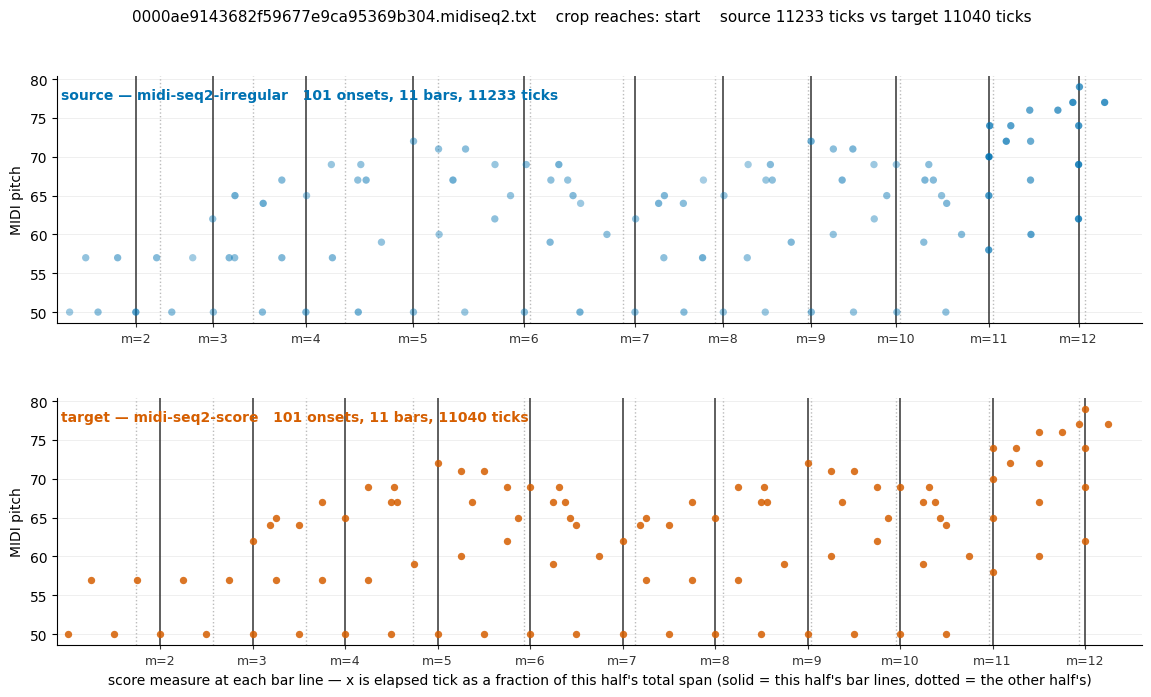

the m= label sits where that measure BEGINS; music left of the first line belongs to measure 1


In [63]:
SOURCE_COLOR = '#0072B2'    # Okabe-Ito blue / vermillion: separable under every common CVD, and
TARGET_COLOR = '#D55E00'    # panel position carries identity anyway, so colour is never the only cue

MAX_TICK_LABELS = 14        # beyond this the m= labels collide, so label every nth bar


def bar_ticks (bars, measures, span):
    """Bar lines -> (scaled positions, 'm=N' labels), thinned to MAX_TICK_LABELS."""
    step = 1 + len(bars) // MAX_TICK_LABELS
    positions, labels = [], []
    for k, bar in enumerate(bars):
        if k % step:
            continue
        positions.append(bar / span)
        # A bar line is where a measure BEGINS, so the number belongs to the music on its right.
        labels.append(f'm={measures[k]}' if k < len(measures) else '?')
    return positions, labels


def draw (ax, notes, bars, end, measures, other_bars, other_end, color, title):
    span = max(1, end)
    x = np.array([t / span for t, _, _ in notes], dtype=float)
    pitch = np.array([p for _, p, _ in notes], dtype=float)
    velocity = np.array([v for _, _, v in notes], dtype=float)
    spread = velocity.max() - velocity.min()
    # Opacity floor keeps a soft note visible; a single-velocity arm maps flat.
    alpha = 0.85 if spread == 0 else 0.35 + 0.55 * (velocity - velocity.min()) / spread

    # The other half's bar lines first, as the reference the solid ones are read against.
    other_span = max(1, other_end)
    for bar in other_bars:
        ax.axvline(bar / other_span, color='#bbbbbb', linewidth=1.0, linestyle=':', zorder=1)
    for bar in bars:
        ax.axvline(bar / span, color='#333333', linewidth=1.1, zorder=2)
    ax.scatter(x, pitch, s=28, marker='o', linewidths=0, color=color, alpha=alpha, zorder=3)

    # Score measure numbers ON the bar lines. Each panel carries its OWN, which is why the two axes
    # are not shared: at these scalings the same x means a different bar in each half.
    positions, labels = bar_ticks(bars, measures, span)
    ax.set_xticks(positions)
    ax.set_xticklabels(labels, fontsize=9)
    ax.tick_params(axis='x', length=3, colors='#333333')

    ax.set_ylabel('MIDI pitch')
    ax.grid(True, axis='y', color='#ececec', linewidth=0.6, zorder=0)
    ax.set_axisbelow(True)
    ax.set_xlim(-0.01, 1.01)
    for side in ('top', 'right'):
        ax.spines[side].set_visible(False)
    # Direct label rather than a legend box: one series per panel, so the title names it.
    ax.text(0.004, 0.95, title, transform=ax.transAxes, va='top', ha='left',
        fontsize=10, color=color, fontweight='bold')


fig, axes = plt.subplots(2, 1, figsize=(14, 7.4), sharey=True,
    gridspec_kw=dict(hspace=0.30))

draw(axes[0], source_notes, source_bars, source_end, source_measures, target_bars, target_end,
    SOURCE_COLOR, f"source — {args['source_dir']}   {len(source_notes)} onsets, "
    f'{len(source_bars)} bars, {source_end} ticks')
draw(axes[1], target_notes, target_bars, target_end, target_measures, source_bars, source_end,
    TARGET_COLOR, f"target — {args['target_dir']}   {len(target_notes)} onsets, "
    f'{len(target_bars)} bars, {target_end} ticks')

axes[1].set_xlabel('score measure at each bar line — x is elapsed tick as a fraction of this half\'s '
    'total span (solid = this half\'s bar lines, dotted = the other half\'s)')
fig.suptitle(f'{name}    crop reaches: {" + ".join(edges) if edges else "neither edge"}    '
    f'source {source_end} ticks vs target {target_end} ticks',
    fontsize=11, y=0.97)
plt.show()

if len(source_bars) != len(source_measures) or len(target_bars) != len(target_measures):
    print(f'!! bar lines and measure numbers disagree: source {len(source_bars)} bars vs '
          f'{len(source_measures)} measures, target {len(target_bars)} vs {len(target_measures)}')
else:
    lead = source_measures[0] - 1 if source_measures else None
    print(f'the m= label sits where that measure BEGINS; music left of the first line belongs to '
          f'measure {lead}')

## 6. Bar-line drift

The same thing as a curve rather than a picture: each bar line's scaled position in one half minus the
other. Flat at zero would mean the two arms keep identical proportional time. A curve that bows away
from zero and comes back is one arm speeding up relative to the other and then being caught up with by
the end — which the shared endpoints force, since both halves are scaled to span exactly [0, 1].

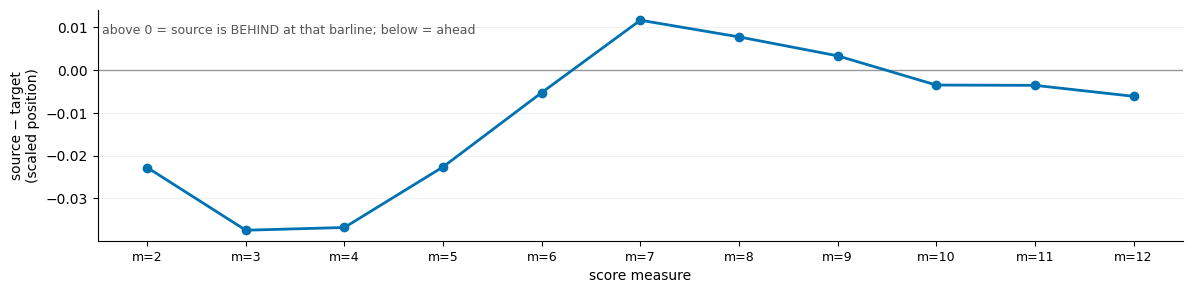

drift range -0.0374 .. +0.0117 (scaled units); as ticks of the source span: -421 .. +131


In [64]:
if len(source_bars) == len(target_bars) and source_bars:
    sx = np.array(source_bars) / max(1, source_end)
    txx = np.array(target_bars) / max(1, target_end)
    drift = sx - txx

    fig, ax = plt.subplots(figsize=(14, 3))
    ax.axhline(0, color='#999999', linewidth=1.0)
    ax.plot(np.arange(len(drift)), drift, marker='o', markersize=6, linewidth=2,
        color=SOURCE_COLOR)
    ax.set_xlabel('score measure')
    ax.set_ylabel('source − target\n(scaled position)')
    ax.set_xticks(np.arange(len(drift)))
    ax.set_xticklabels([f'm={m}' for m in source_measures[:len(drift)]], fontsize=9)
    ax.grid(True, axis='y', color='#ececec', linewidth=0.6)
    ax.set_axisbelow(True)
    for side in ('top', 'right'):
        ax.spines[side].set_visible(False)
    ax.text(0.004, 0.94, 'above 0 = source is BEHIND at that barline; below = ahead',
        transform=ax.transAxes, va='top', fontsize=9, color='#555555')
    plt.show()

    print(f'drift range {drift.min():+.4f} .. {drift.max():+.4f} (scaled units); '
          f'as ticks of the source span: {drift.min() * source_end:+.0f} .. '
          f'{drift.max() * source_end:+.0f}')
else:
    print('bar counts differ — no drift curve')

## 7. Did the crop actually align?

Tempo is now visible, which means it is also in the way of the alignment question. Dividing it out —
normalizing each bar by its own span — answers that: for each target onset, the nearest source onset
of the same pitch, measured in bar units. A median well under 0.05 means the two halves are describing
the same music; the residual spread is the per-note humanization, which is small (median 45 ticks,
about 2.3% of a 1920-tick bar) and would be invisible in the plot above at any width.

In [65]:
def bar_position (notes, bars, end):
    """tick -> bar_index + fraction through that bar. Divides tempo out, unlike the plot's axis."""
    if not bars:
        span = max(1, end)
        return [(t / span, p, v) for t, p, v in notes]
    edges = list(bars) + [end + 1]
    out = []
    for tick, pitch, velocity in notes:
        if tick < edges[0]:
            out.append(((tick - edges[0]) / max(1, edges[0]), pitch, velocity))
            continue
        k = min(np.searchsorted(edges, tick, side='right') - 1, len(edges) - 2)
        span = max(1, edges[k + 1] - edges[k])
        out.append((k + (tick - edges[k]) / span, pitch, velocity))
    return out


def alignment_deviation (s_notes, s_bars, s_end, t_notes, t_bars, t_end):
    s_points = bar_position(s_notes, s_bars, s_end)
    t_points = bar_position(t_notes, t_bars, t_end)
    devs = []
    for x, pitch, _ in t_points:
        same_pitch = [abs(x - xs) for xs, ps, _ in s_points if ps == pitch]
        if same_pitch:
            devs.append(min(same_pitch))
    devs.sort()
    return devs


devs = alignment_deviation(source_notes, source_bars, source_end,
    target_notes, target_bars, target_end)
if devs:
    print(f'nearest same-pitch onset, in bar units: median {devs[len(devs) // 2]:.4f}  '
          f'p90 {devs[int(len(devs) * 0.9)]:.4f}  max {devs[-1]:.4f}')
    print('-> the crop aligned' if devs[len(devs) // 2] < 0.05
        else '-> SUSPECT: the halves may not be covering the same music')

nearest same-pitch onset, in bar units: median 0.0132  p90 0.0471  max 0.3542
-> the crop aligned


## 8. Per-bar onset counts

How many onsets each half puts in each bar. The counts need not match — a performance may split a
written chord or drop a doubled note, and the score arm sounds a trill as its single principal note —
but they should be comparable, and a bar with music on one side should have music on the other.

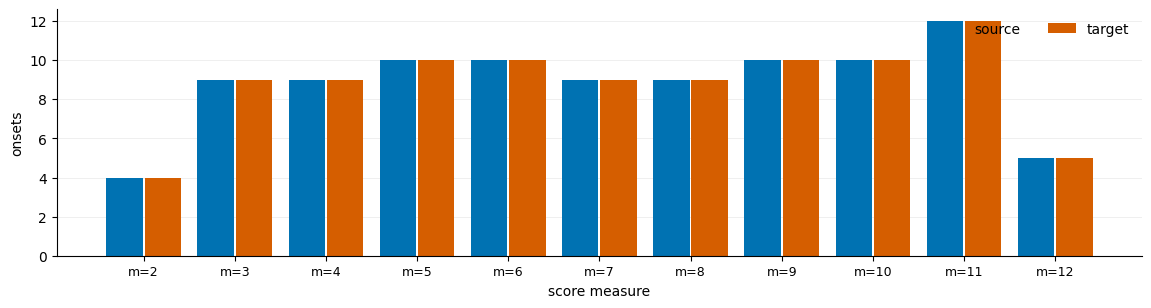

leading partial bar: source 4 onsets, target 4
bars with music on one side only: none


In [66]:
def per_bar_counts (notes, bars, end):
    width = max(1, len(bars))
    counts = [0] * width
    lead = 0
    for x, _, _ in bar_position(notes, bars, end):
        if x < 0:
            lead += 1
            continue
        counts[min(int(x), width - 1)] += 1
    return counts, lead


source_counts, source_lead = per_bar_counts(source_notes, source_bars, source_end)
target_counts, target_lead = per_bar_counts(target_notes, target_bars, target_end)
width = max(len(source_counts), len(target_counts))
source_counts += [0] * (width - len(source_counts))
target_counts += [0] * (width - len(target_counts))

x = np.arange(width)
fig, ax = plt.subplots(figsize=(14, 3.2))
# A visible gap between the paired bars keeps them readable when the counts are close.
ax.bar(x - 0.21, source_counts, width=0.40, color=SOURCE_COLOR, label='source')
ax.bar(x + 0.21, target_counts, width=0.40, color=TARGET_COLOR, label='target')
ax.set_xlabel('score measure')
ax.set_ylabel('onsets')
ax.set_xticks(x)
# Bar k of the crop is the k-th <eom>, hence the k-th measure the feeder reported.
ax.set_xticklabels([f'm={source_measures[k]}' if k < len(source_measures) else f'#{k}'
    for k in range(width)], fontsize=9)
ax.grid(True, axis='y', color='#ececec', linewidth=0.6)
ax.set_axisbelow(True)
for side in ('top', 'right'):
    ax.spines[side].set_visible(False)
ax.legend(frameon=False, ncol=2, loc='upper right')
plt.show()

print(f'leading partial bar: source {source_lead} onsets, target {target_lead}')
lopsided = [f'm={source_measures[i]}' if i < len(source_measures) else f'#{i}'
    for i in range(width) if bool(source_counts[i]) != bool(target_counts[i])]
print('bars with music on one side only:', ', '.join(lopsided) if lopsided else 'none')

## 9. Sweep a few samples

Per sample: bar count, the alignment deviation (must stay small — that is correctness), and the tempo
spread (need NOT be small — that is the signal). `max|Δx|` is the largest bar-line drift in scaled
units, so a bigger number means a more strongly rubato performance, not a worse pair.

In [67]:
print(f'{"#":>3}  {"sample":18s} {"T":>6} {"src":>5} {"tgt":>5} {"bars":>9} {"measures":>12} '
      f'{"dev":>7} {"max|dx|":>8}')
issues = 0
for k in range(min(12, len(train))):
    case_k = train.describe(train.indices[k])
    toks_k = [tk.tokens[i] for i in case_k['ids']]
    sep_k = case_k['sep']
    s_notes, s_bars, s_end = decode_onsets(toks_k[:sep_k])
    t_notes, t_bars, t_end = decode_onsets(toks_k[sep_k + 1:])
    s_meas = [m for _, m in case_k['source_measures'] if m != 1]

    devs_k = alignment_deviation(s_notes, s_bars, s_end, t_notes, t_bars, t_end)
    median_dev = devs_k[len(devs_k) // 2] if devs_k else float('nan')
    if len(s_bars) == len(t_bars) and s_bars:
        drift_k = max(abs(s / max(1, s_end) - t / max(1, t_end)) for s, t in zip(s_bars, t_bars))
    else:
        drift_k = float('nan')

    span = f'{s_meas[0]}..{s_meas[-1]}' if s_meas else '-'
    # A bar line with no measure number (or the reverse) would break every m= label above.
    ok = len(s_bars) == len(t_bars) and len(s_bars) == len(s_meas) \
        and (not devs_k or median_dev < 0.1)
    if not ok:
        issues += 1
    print(f'{k:>3}  {case_k["name"][:18]:18s} {len(case_k["ids"]):>6} {len(s_notes):>5} '
        f'{len(t_notes):>5} {len(s_bars):>4}/{len(t_bars):<4} {span:>12} {median_dev:>7.4f} '
        f'{drift_k:>8.4f}{"  <-- check" if not ok else ""}')

print(f'\n{issues} sample(s) flagged' if issues
    else '\nall sampled pairs agree on bar count, carry a measure number per bar line, and align '
    'within 0.1 bar units')
print('the max|dx| column is tempo divergence — larger is a more rubato performance, not a worse pair')

  #  sample                  T   src   tgt      bars     measures     dev  max|dx|
  0  00000121f169d244fd   1932    96    90    5/5          34..38  0.0094   0.0185
  1  00001d5d7c31a66c13   2283   101   114    7/7           9..15  0.0135   0.0667
  2  00002624300c9dcd38   2211   114   114    4/4          14..17  0.0114   0.0670
  3  0000514ceaa9ea07c1   1849   117   117    7/7          27..33  0.0120   0.0158
  4  0000515a6217a10f86   1801   108   111    9/9          29..37  0.0089   0.0213
  5  0000563b05577dc646   1747    87    90    5/5          38..42  0.0190   0.0357
  6  00005be719ecc9f97c   1996   104   137    9/9          50..58  0.0611   0.0245
  7  000077ca0f1dc9313d   2296   121   122   10/10          2..11  0.0498   0.0687
  8  0000ae9143682f5967   1827   101   101   11/11          2..12  0.0132   0.0374
  9  0000d32362fe8ce09e   1824    92    95    8/8            2..9  0.0127   0.0117
 10  0000eb5fa47d996f21   2327   110   110    6/6          57..62  0.0137   0.0150
 11 